### Mutual Fund NAV Prediction using Linear Regression

The objective of this project is to predict the Net Asset Value (NAV) of mutual funds using Linear Regression based on available fund characteristics.

## Step 1: Import Libraries and Load the Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as py

from sklearn.linear_model import LinearRegression,Lasso,Ridge,ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error , mean_squared_error , root_mean_squared_error , r2_score
from sklearn.preprocessing import StandardScaler,LabelEncoder

import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")

import joblib
import pickle

In [2]:
df = pd.read_csv("Mutual Fund NAV - LR.csv")
df.head()

,Scheme_Code,Scheme_Name,AMC,Scheme_Type,Scheme_Category,Scheme_NAV_Name,Scheme_Min_Amt,NAV,Latest_NAV_Date,Average_AUM_Cr
0,100033,Aditya Birla Sun Life Large & Mid Cap Fund,Aditya Birla Sun Life AMC Limited,Open Ended,Equity Scheme - Large & Mid Cap Fund,Aditya Birla Sun Life Large & Mid Cap Fund - R...,5000,926.4600,2026-07-23,4452.7672
1,100034,Aditya Birla Sun Life Large & Mid Cap Fund,Aditya Birla Sun Life AMC Limited,Open Ended,Equity Scheme - Large & Mid Cap Fund,Aditya Birla Sun Life Large & Mid Cap Fund -Re...,5000,134.9300,2026-07-23,455.1745
2,100037,Aditya Birla Sun Life Income Fund,Aditya Birla Sun Life AMC Limited,Open Ended,Debt Scheme - Medium to Long Duration Fund,Aditya Birla Sun Life Income Fund - Regular - ...,5000,13.0536,2026-07-23,10.9823
3,100038,Aditya Birla Sun Life Income Fund,Aditya Birla Sun Life AMC Limited,Open Ended,Debt Scheme - Medium to Long Duration Fund,Aditya Birla Sun Life Income Fund - Growth - R...,5000,129.6436,2026-07-23,724.9003
4,100039,Aditya Birla Sun Life Income Fund,Aditya Birla Sun Life AMC Limited,Open Ended,Debt Scheme - Medium to Long Duration Fund,Birla Income Plus-Institutional (Growth),5000,NaN,NaN,NaN


In [3]:
df.shape

(16288, 10)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16288 entries, 0 to 16287
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Scheme_Code      16288 non-null  int64  
 1   Scheme_Name      16288 non-null  object 
 2   AMC              16288 non-null  object 
 3   Scheme_Type      16288 non-null  object 
 4   Scheme_Category  16288 non-null  object 
 5   Scheme_NAV_Name  16288 non-null  object 
 6   Scheme_Min_Amt   16258 non-null  object 
 7   NAV              14199 non-null  float64
 8   Latest_NAV_Date  14199 non-null  object 
 9   Average_AUM_Cr   8204 non-null   float64
dtypes: float64(2), int64(1), object(7)
memory usage: 1.2+ MB


In [5]:
df.describe()

,Scheme_Code,NAV,Average_AUM_Cr
count,16288.000000,1.419900e+04,8204.000000
mean,136963.594487,1.661941e+03,1030.898656
std,15494.781668,5.318225e+04,4983.168992
min,100033.000000,0.000000e+00,0.000100
25%,125888.750000,1.114975e+01,0.597475
50%,142245.500000,1.321340e+01,13.111000
75%,149359.250000,3.051565e+01,240.749500
max,154547.000000,2.510326e+06,206968.266800


In [6]:
df.describe(include="all")

,Scheme_Code,Scheme_Name,AMC,Scheme_Type,Scheme_Category,Scheme_NAV_Name,Scheme_Min_Amt,NAV,Latest_NAV_Date,Average_AUM_Cr
count,16288.000000,16288,16288,16288,16288,16288,16258,1.419900e+04,14199,8204.000000
unique,NaN,3709,54,3,80,16251,562,NaN,823,NaN
top,NaN,Franklin India Short-Term Income Plan (no. of ...,ICICI Prudential Asset Management Company Limited,Open Ended,Income,Kotak Bond-Deposit-Dividend,5000,NaN,2026-07-23,NaN
freq,NaN,45,3321,10086,6084,4,4999,NaN,8597,NaN
mean,136963.594487,NaN,NaN,NaN,NaN,NaN,NaN,1.661941e+03,NaN,1030.898656
std,15494.781668,NaN,NaN,NaN,NaN,NaN,NaN,5.318225e+04,NaN,4983.168992
min,100033.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,NaN,0.000100
25%,125888.750000,NaN,NaN,NaN,NaN,NaN,NaN,1.114975e+01,NaN,0.597475
50%,142245.500000,NaN,NaN,NaN,NaN,NaN,NaN,1.321340e+01,NaN,13.111000
75%,149359.250000,NaN,NaN,NaN,NaN,NaN,NaN,3.051565e+01,NaN,240.749500


## Step 2: Clean the Data

In [7]:
df.isnull().sum()

Scheme_Code           0
Scheme_Name           0
AMC                   0
Scheme_Type           0
Scheme_Category       0
Scheme_NAV_Name       0
Scheme_Min_Amt       30
NAV                2089
Latest_NAV_Date    2089
Average_AUM_Cr     8084
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df1 = df.drop_duplicates()                 #since there are no duplicate entries we actually dont need this tep
df1.shape

(16288, 10)

#### A : Remove rows where NAV is missing

In [10]:
df1 = df1.dropna(subset=['NAV'])

In [11]:
df1.shape

(14199, 10)

In [12]:
df.shape

(16288, 10)

#### B: Fill missing values in Scheme_Min_Amt

##### Step 1: Extract the Investment Amount

In [13]:
#Since the column contains long text, we only need the first number.

df1['Scheme_Min_Amt']=df1['Scheme_Min_Amt'].str.extract('(\d+)')

#Let's break it down:
#df["Scheme_Min_Amt"] --> Selects the Scheme_Min_Amt column.
#.str --> Tells pandas that we want to perform a string (text) operation
#.extract() --> extracts a specific part of the text.
#'(\d+)' --> Find the first sequence of numbers.

##### Step 2: Convert to Numeric

In [14]:
df1['Scheme_Min_Amt'] = pd.to_numeric(df1['Scheme_Min_Amt'])

##### Why this we do this?
Machine Learning algorithms require numerical data for calculations. This step converts the extracted text values into numeric values.

##### Step 3: Check Missing Values Again

In [15]:
df1['Scheme_Min_Amt'].isnull().sum()        ##This tells us how many values couldn't be converted into numbers.

np.int64(144)

##### Step 4: Fill Missing Values

In [16]:
df1['Scheme_Min_Amt']=df1['Scheme_Min_Amt'].fillna(df1['Scheme_Min_Amt'].median())

##Why median instead of mean?
#The investment amounts vary a lot (₹100, ₹500, ₹5000, ₹50,000, etc.). Such data is often skewed.
#The median is less affected by very large or very small values, so it's a more robust choice for filling missing numerical data.

In [17]:
#Re-check
df1['Scheme_Min_Amt'].isnull().sum()

np.int64(0)

#### C: Handle Missing Values in Average_AUM_Cr

In [18]:
df1["Average_AUM_Cr"] = df1["Average_AUM_Cr"].fillna(df1["Average_AUM_Cr"].median())

In [19]:
#Re-check:
df1["Average_AUM_Cr"].isnull().sum()

np.int64(0)

In [20]:
#Verify : 
df1.isnull().sum()

Scheme_Code        0
Scheme_Name        0
AMC                0
Scheme_Type        0
Scheme_Category    0
Scheme_NAV_Name    0
Scheme_Min_Amt     0
NAV                0
Latest_NAV_Date    0
Average_AUM_Cr     0
dtype: int64

### Step 3: Exploratory Data Analysis (EDA)

##### NOTE:
Exploratory Data Analysis (EDA) is performed to understand the dataset, identify patterns, analyze the distribution of variables, detect outliers, and explore relationships between different features before building the machine learning model.

#### A. Distribution of NAV

This plot shows how the target variable (NAV) is distributed across the dataset.

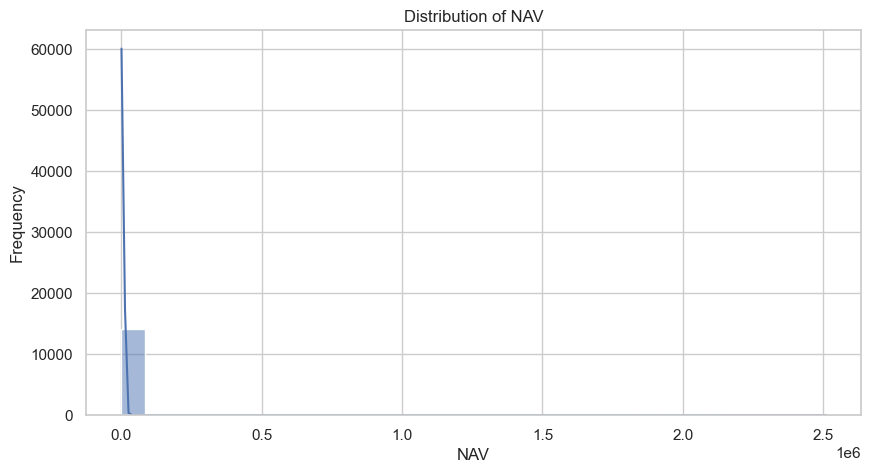

In [21]:
plt.figure(figsize=(10,5))

sns.histplot(df1["NAV"], bins=30, kde=True)

plt.title("Distribution of NAV")
plt.xlabel("NAV")
plt.ylabel("Frequency")

plt.show()

#### Interpretation:
The histogram shows the distribution of NAV values. It helps identify whether the target variable is normally distributed or skewed.

#### B. Distribution of Scheme Type

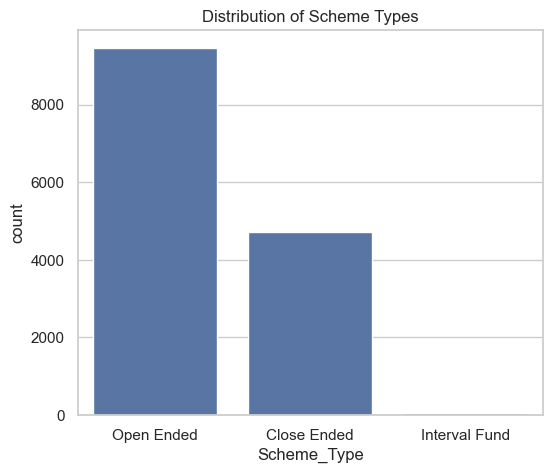

In [22]:
plt.figure(figsize=(6,5))

sns.countplot(x="Scheme_Type", data=df1)

plt.title("Distribution of Scheme Types")

plt.show()

#### Interpretation:
This graph shows the number of schemes available under each scheme type.

#### C. Top 10 Asset Management Companies (AMCs)

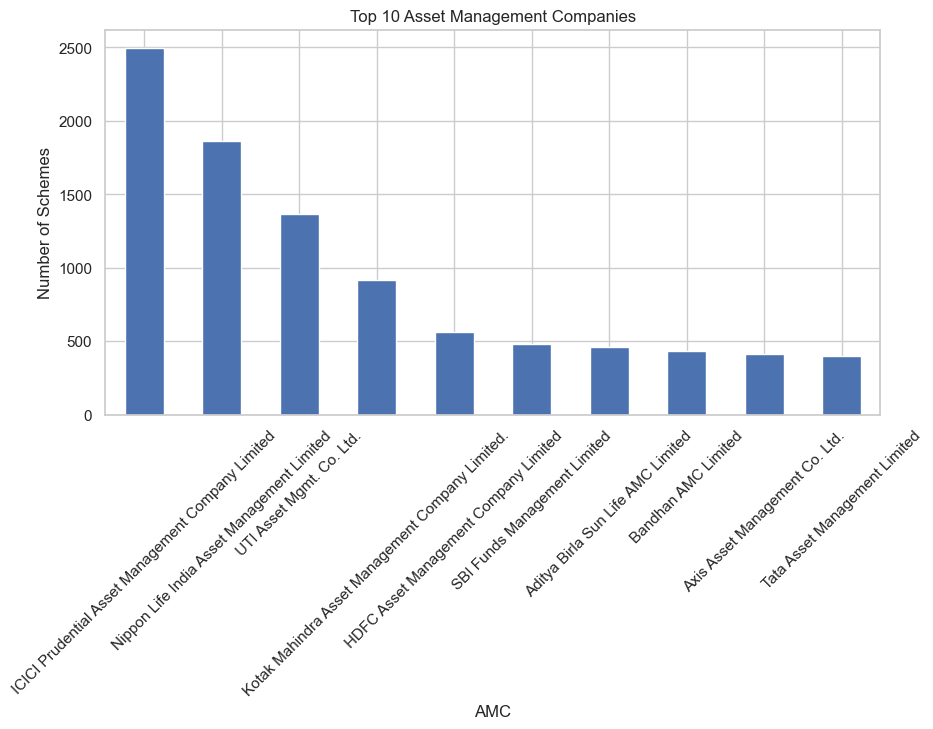

In [23]:
plt.figure(figsize=(10,5))

df1["AMC"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Asset Management Companies")
plt.xlabel("AMC")
plt.ylabel("Number of Schemes")

plt.xticks(rotation=45)

plt.show()

#### D. Top 10 Scheme Categories

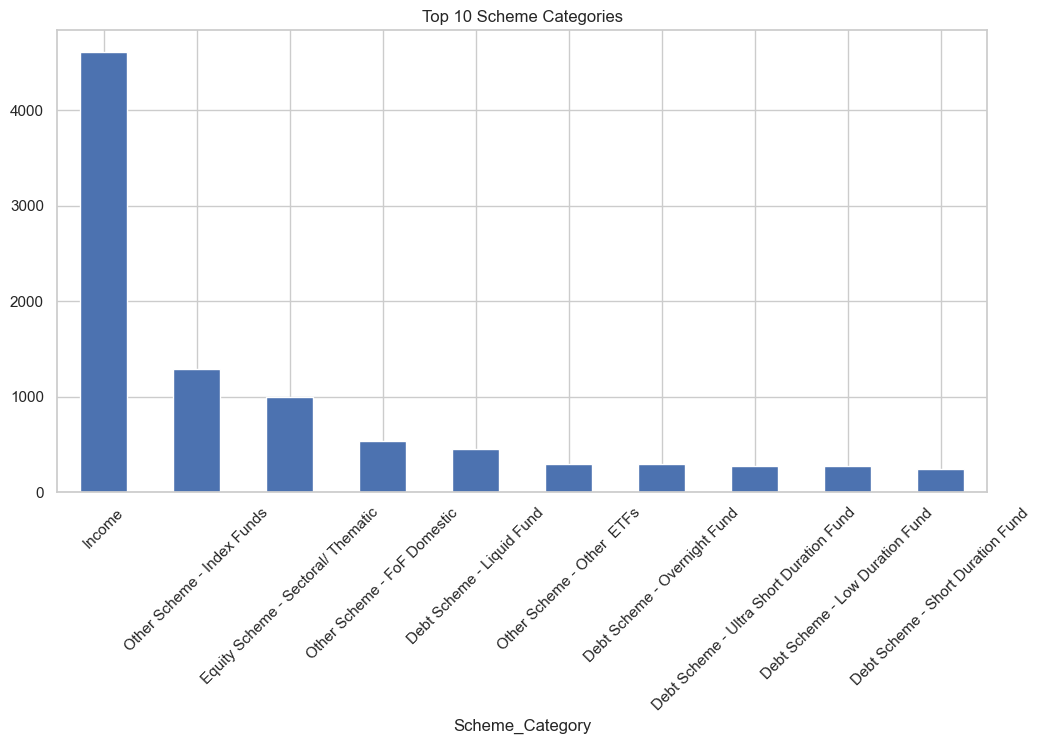

In [24]:
plt.figure(figsize=(12,6))

df1["Scheme_Category"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Scheme Categories")

plt.xticks(rotation=45)

plt.show()

#### E. Distribution of Minimum Investment Amount

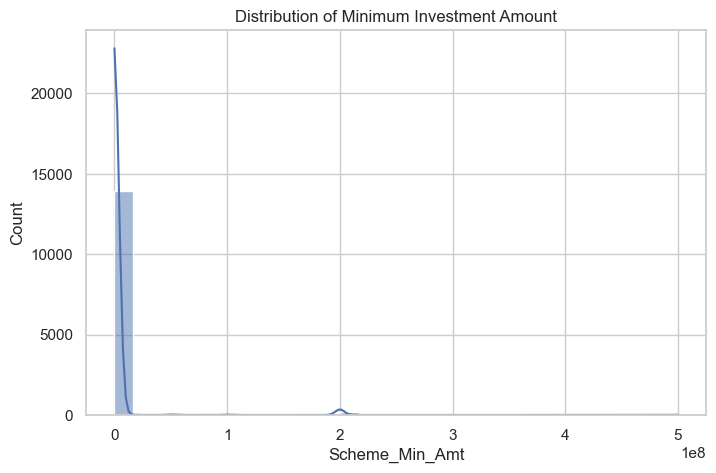

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(df1["Scheme_Min_Amt"], bins=30, kde=True)

plt.title("Distribution of Minimum Investment Amount")

plt.show()

#### F. Distribution of Average AUM

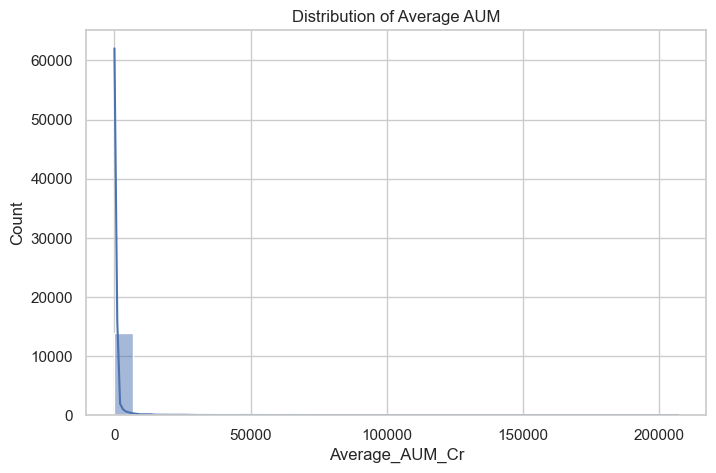

In [26]:
plt.figure(figsize=(8,5))

sns.histplot(df1["Average_AUM_Cr"], bins=30, kde=True)

plt.title("Distribution of Average AUM")

plt.show()

#### G. Boxplots

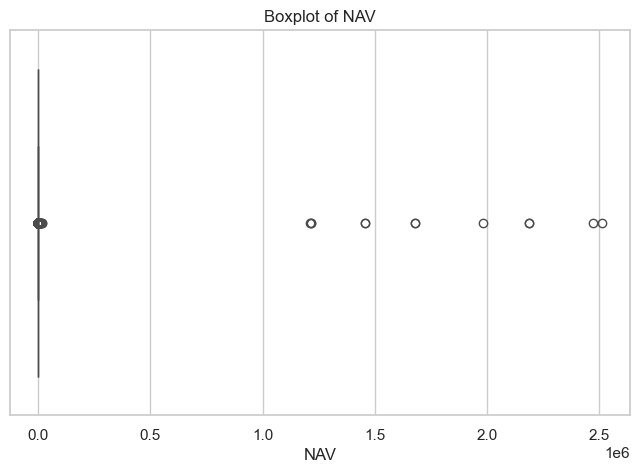

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df1["NAV"])

plt.title("Boxplot of NAV")

plt.show()

## Step 4: Remove Outliers

In [28]:
Q1 = df1['NAV'].quantile(0.25)
Q3 = df1['NAV'].quantile(0.75)
IQR = Q3 - Q1

lower_NAV = Q1 - 1.5 * IQR
upper_NAV = Q3 + 1.5 * IQR

print("Lower limit:", lower_NAV)
print("Upper limit:", upper_NAV)


Lower limit: -17.8991
Upper limit: 59.5645


In [29]:
outliers = df1[(df1['NAV'] < lower_NAV) | (df1['NAV'] > upper_NAV)]
print("Number of outliers:", len(outliers))

Number of outliers: 2487


In [30]:
df2 = df1[(df1["NAV"] >= lower_NAV) & (df1["NAV"] <= upper_NAV)]
print("Shape before removing outliers:", df1.shape)
print("Shape after removing outliers:", df2.shape)

Shape before removing outliers: (14199, 10)
Shape after removing outliers: (11712, 10)


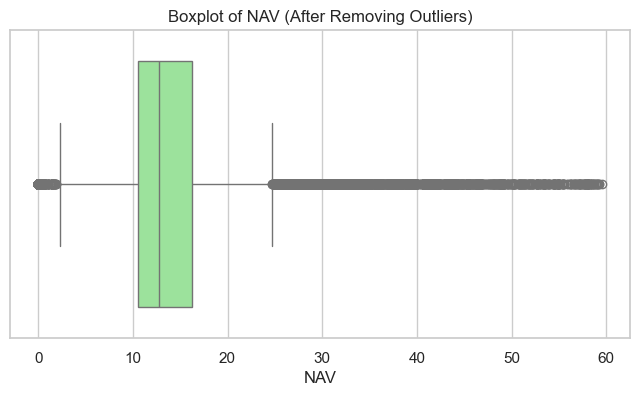

In [31]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df2["NAV"], color="lightgreen")
plt.title("Boxplot of NAV (After Removing Outliers)")
plt.show()


In [32]:
df2.columns

Index(['Scheme_Code', 'Scheme_Name', 'AMC', 'Scheme_Type', 'Scheme_Category',
       'Scheme_NAV_Name', 'Scheme_Min_Amt', 'NAV', 'Latest_NAV_Date',
       'Average_AUM_Cr'],
      dtype='object')

In [33]:
df3 = df2.drop(columns=["Scheme_Code", "Scheme_Name","Scheme_NAV_Name","Latest_NAV_Date"])
df3.head()

,AMC,Scheme_Type,Scheme_Category,Scheme_Min_Amt,NAV,Average_AUM_Cr
2,Aditya Birla Sun Life AMC Limited,Open Ended,Debt Scheme - Medium to Long Duration Fund,5000.0,13.0536,10.9823
15,Aditya Birla Sun Life AMC Limited,Open Ended,Debt Scheme - Gilt Fund,5000.0,10.7735,2.9922
19,DSP Asset Managers Private Limited,Open Ended,Debt Scheme - Medium Duration Fund,1000.0,11.6637,5.9579
21,DSP Asset Managers Private Limited,Open Ended,Debt Scheme - Medium Duration Fund,1000.0,11.2240,0.2403
22,DSP Asset Managers Private Limited,Open Ended,Equity Scheme - Flexi Cap Fund,1000.0,57.8030,349.6687


In [34]:
x = df3.drop("NAV", axis=1)
y = df3["NAV"]
print(x.shape, y.shape)

(11712, 5) (11712,)


In [35]:
df3.columns

Index(['AMC', 'Scheme_Type', 'Scheme_Category', 'Scheme_Min_Amt', 'NAV',
       'Average_AUM_Cr'],
      dtype='object')

In [36]:
x = pd.get_dummies(x,columns=['AMC','Scheme_Type','Scheme_Category'],drop_first=True,dtype="int")
x.head()

,Scheme_Min_Amt,Average_AUM_Cr,AMC_Abakkus Investment Managers Private Limited,AMC_Aditya Birla Sun Life AMC Limited,AMC_Angel One Asset Management Company Limited,AMC_Axis Asset Management Co. Ltd.,AMC_Bajaj Finserv Asset Management Limited,AMC_Bandhan AMC Limited,AMC_Bank of India Investment Managers Private Limited,AMC_Baroda BNP Paribas Asset Management India Private Limited,...,Scheme_Category_Index Funds - Equity Funds,Scheme_Category_Money Market,Scheme_Category_Other Scheme - FoF Domestic,Scheme_Category_Other Scheme - FoF Overseas,Scheme_Category_Other Scheme - Gold ETF,Scheme_Category_Other Scheme - Index Funds,Scheme_Category_Other Scheme - Other ETFs,Scheme_Category_Overseas Fund of Funds - Fund of Funds investing overseas,Scheme_Category_Solution Oriented Scheme - Children s Fund,Scheme_Category_Solution Oriented Scheme - Retirement Fund
2,5000.0,10.9823,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
15,5000.0,2.9922,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
19,1000.0,5.9579,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
21,1000.0,0.2403,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
22,1000.0,349.6687,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [37]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print("Train size:", x_train.shape)
print("Test size:", x_test.shape)

Train size: (9369, 119)
Test size: (2343, 119)


In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [39]:
lin_model = LinearRegression()
lin_model.fit(x_train_scaled, y_train)

lin_train_r2 = lin_model.score(x_train_scaled, y_train)

lin_pred = lin_model.predict(x_test_scaled)

lin_test_r2 = r2_score(y_test,lin_pred)
lin_mae = mean_absolute_error(y_test, lin_pred)
lin_rmse = np.sqrt(mean_squared_error(y_test, lin_pred))

print("Linear Regression")
print("Train R2 :", round(lin_train_r2, 4))
print("Test  R2 :", round(lin_test_r2, 4))
print("MAE      :", round(lin_mae, 2))
print("RMSE     :", round(lin_rmse, 2))

Linear Regression
Train R2 : 0.3459
Test  R2 : 0.3247
MAE      : 4.83
RMSE     : 7.76


In [40]:
lasso_model = Lasso(alpha=0.5, random_state=42, max_iter=50000)
lasso_model.fit(x_train_scaled, y_train)

lasso_train_r2 = lasso_model.score(x_train_scaled, y_train)

lasso_pred = lasso_model.predict(x_test_scaled)

lasso_test_r2 = r2_score(y_test, lasso_pred)

lasso_mae = mean_absolute_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))

print("Lasso Regression")
print("Train R2 :", round(lasso_train_r2, 4))
print("Test  R2 :", round(lasso_test_r2, 4))
print("MAE      :", round(lasso_mae, 2))
print("RMSE     :", round(lasso_rmse, 2))

Lasso Regression
Train R2 : 0.2166
Test  R2 : 0.2292
MAE      : 5.2
RMSE     : 8.29


In [41]:
ridge_model = Ridge(alpha=0.5, random_state=42)
ridge_model.fit(x_train_scaled, y_train)

ridge_train_r2 = ridge_model.score(x_train_scaled, y_train)

ridge_pred = ridge_model.predict(x_test_scaled)

ridge_test_r2 = r2_score(y_test, ridge_pred)
ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))

print("Ridge Regression")
print("Train R2 :", round(ridge_train_r2, 4))
print("Test  R2 :", round(ridge_test_r2, 4))
print("MAE      :", round(ridge_mae, 2))
print("RMSE     :", round(ridge_rmse, 2))

Ridge Regression
Train R2 : 0.3459
Test  R2 : 0.3247
MAE      : 4.83
RMSE     : 7.76


In [42]:
elastic_model = ElasticNet(alpha=0.5, l1_ratio=0.5, random_state=42, max_iter=50000)
elastic_model.fit(x_train_scaled, y_train)

elastic_train_r2 = elastic_model.score(x_train_scaled, y_train)

elastic_pred = elastic_model.predict(x_test_scaled)
elastic_test_r2 = r2_score(y_test, elastic_pred)

elastic_mae = mean_absolute_error(y_test, elastic_pred)
elastic_rmse = np.sqrt(mean_squared_error(y_test, elastic_pred))

print("ElasticNet Regression (alpha=2, l1_ratio=0.5)")
print("Train R2 :", round(elastic_train_r2, 4))
print("Test  R2 :", round(elastic_test_r2, 4))
print("MAE      :", round(elastic_mae, 2))
print("RMSE     :", round(elastic_rmse, 2))

ElasticNet Regression (alpha=2, l1_ratio=0.5)
Train R2 : 0.2629
Test  R2 : 0.2712
MAE      : 5.05
RMSE     : 8.06


In [43]:
results_df = pd.DataFrame([
    {"Model": "Linear Regression",     "Train R2": lin_train_r2,     "Test R2": lin_test_r2,     "MAE": lin_mae,     "RMSE": lin_rmse},
    {"Model": "Lasso Regression",      "Train R2": lasso_train_r2,   "Test R2": lasso_test_r2,   "MAE": lasso_mae,   "RMSE": lasso_rmse},
    {"Model": "Ridge Regression",      "Train R2": ridge_train_r2,   "Test R2": ridge_test_r2,   "MAE": ridge_mae,   "RMSE": ridge_rmse},
    {"Model": "ElasticNet Regression", "Train R2": elastic_train_r2, "Test R2": elastic_test_r2, "MAE": elastic_mae, "RMSE": elastic_rmse},
])
results_df

,Model,Train R2,Test R2,MAE,RMSE
0,Linear Regression,0.345861,0.324704,4.833159,7.756151
1,Lasso Regression,0.216557,0.229189,5.199294,8.286533
2,Ridge Regression,0.345861,0.324715,4.833095,7.756083
3,ElasticNet Regression,0.262909,0.271176,5.054489,8.057685


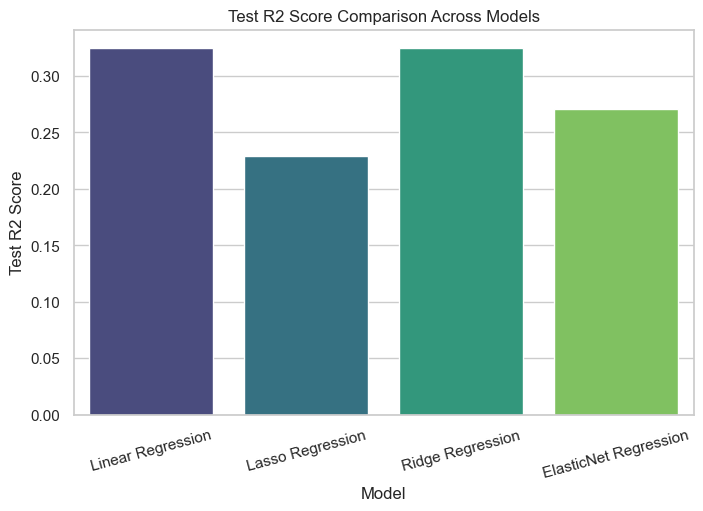

In [44]:
plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="Test R2", data=results_df, palette="viridis")
plt.title("Test R2 Score Comparison Across Models")
plt.ylabel("Test R2 Score")
plt.xticks(rotation=15)
plt.show()

In [45]:
best_name = results_df.loc[results_df["Test R2"].idxmax(), "Model"]
print("Best Model:", best_name)

if best_name == "Linear Regression":
    best_predictions = lin_pred             
elif best_name == "Lasso Regression":
    best_predictions = lasso_pred             
elif best_name == "Ridge Regression":
    best_predictions = ridge_pred             
else:
    best_predictions = elastic_pred             

Best Model: Ridge Regression


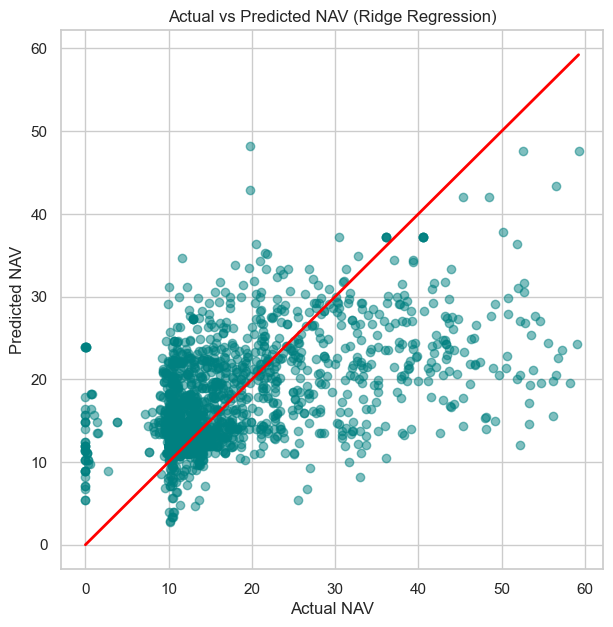

In [46]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, best_predictions, alpha=0.5, color="teal")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linewidth=2)
plt.xlabel("Actual NAV")
plt.ylabel("Predicted NAV")
plt.title(f"Actual vs Predicted NAV ({best_name})")
plt.show()

In [47]:
print("Training R2 Score:", lin_model.score(x_train_scaled, y_train))
print("Testing R2 Score:", lin_model.score(x_test_scaled, y_test))

Training R2 Score: 0.3458608371959332
Testing R2 Score: 0.32470365863449235
